In [26]:
import rasterio
import matplotlib.pyplot as plt
import requests
import io
import xarray as xr

In [27]:
# open an example geotiff from the API repo
fp = '/Users/SNAP/repo/data-api/geotiffs/annual_mean_temp.tif'
with rasterio.open(fp) as src:
    print(src.profile)
    print(src.crs)
    print(src.bounds)
    print(src.width, src.height)
    print(src.count)  # number of bands
    band1 = src.read(1)  # read the first band
    # print unique values in the band
    print(set(band1.flatten()))

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 1849, 'height': 999, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Alaska Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",50],PARAMETER["longitude_of_center",-154],PARAMETER["standard_parallel_1",55],PARAMETER["standard_parallel_2",65],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3338"]]'), 'transform': Affine(2000.0, 0.0, -2187223.206087799,
       0.0, -2000.0, 2394412.932644147), 'blockxsize': 1849, 'blockysize': 4, 'tiled': False, 'interleave': 'band'}
EPSG:3338
BoundingBox(left=-2187223.206087799, bottom

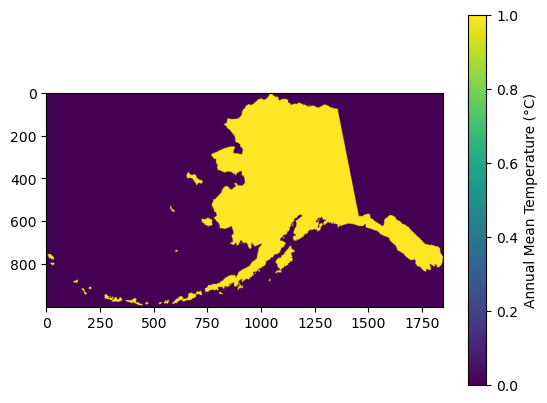

In [28]:
# plot the geotiff with a colormap legend
plt.imshow(band1, cmap='viridis')
plt.colorbar(label='Annual Mean Temperature (°C)')

In [29]:
# from this example, we see that we want areas with data to =1 and nodata to =0
# load a netCDF from one of the CMIP6 fire weather coverages
# all variables should have the same extent, and we only need a single timestep

url = 'https://zeus.snap.uaf.edu/rasdaman/ows?&SERVICE=WCS&VERSION=2.0.1&REQUEST=GetCoverage&COVERAGEID=cmip6_fwi&SUBSET=model(0)&SUBSET=time(0)&FORMAT=application/netcdf'

r = requests.get(url)
ds = xr.open_dataset(io.BytesIO(r.content))


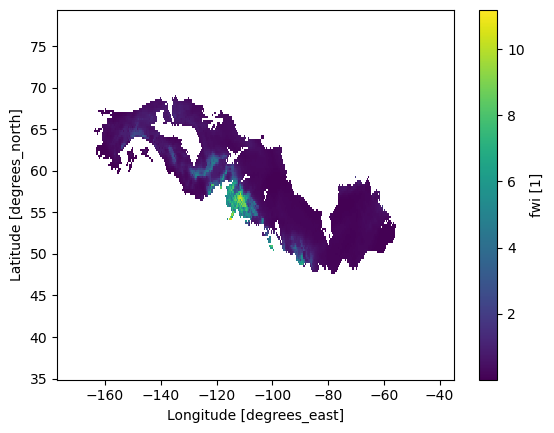

In [30]:
ds["fwi"].plot()

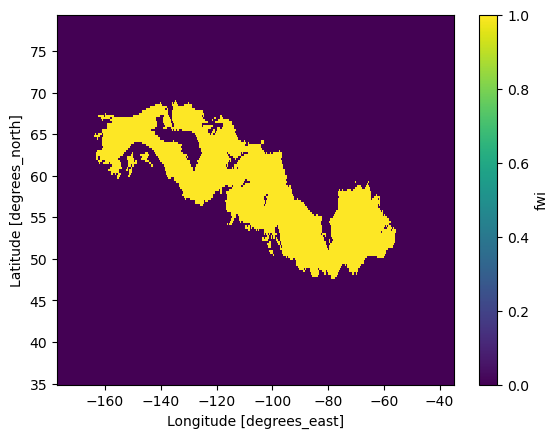

In [31]:
# replace all non-nan values with 1, and nan values with 0
fwi_binary = ds["fwi"].notnull().astype(int)
fwi_binary.plot()

In [32]:
# save as geotiff, making sure to include CRS info
fwi_binary.rio.write_crs("EPSG:4326", inplace=True)
fwi_binary.rio.to_raster("cmip6_all_fire_weather_variables.tif")

In [34]:
# open the saved geotiff and check the values
with rasterio.open("cmip6_all_fire_weather_variables.tif") as src:
    print(src.profile)
    band1 = src.read(1)
    print(set(band1.flatten()))

{'driver': 'GTiff', 'dtype': 'int64', 'nodata': None, 'width': 569, 'height': 178, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.25, 0.0, -177.125,
       0.0, -0.25, 79.375), 'blockxsize': 569, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}
{0, 1}


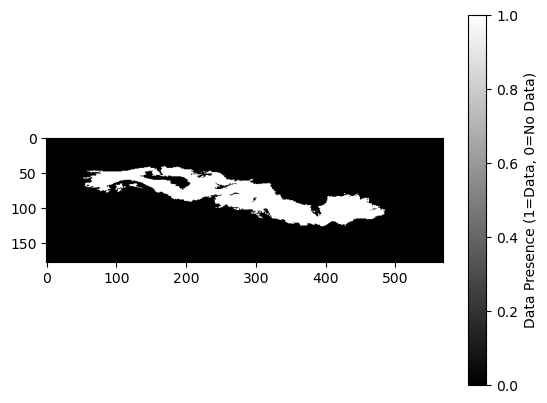

In [35]:
# and plot with colormap legend
plt.imshow(band1, cmap='gray')
plt.colorbar(label='Data Presence (1=Data, 0=No Data)')